<a href="https://colab.research.google.com/github/Genjis0604/Documentos/blob/main/predicci%C3%B3n_precios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Predicción de precios con XGBOOST
#Importar librerias
!pip install xgboost
!pip install yfinance

In [2]:
import time
import numpy as pd
import yfinance as yf
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [3]:
## Cargar datos
df = yf.download("QQQ", start="2010-01-04", end="2024-01-01", interval="1d", auto_adjust=True)
print(df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

(3522, 5)
Price           Close       High        Low       Open    Volume
Ticker            QQQ        QQQ        QQQ        QQQ       QQQ
Date                                                            
2010-01-04  40.341591  40.402428  40.211234  40.263379  62822800
2010-01-05  40.341591  40.411117  40.115638  40.315520  62935600
2010-01-06  40.098259  40.454572  40.037425  40.324215  96033000
2010-01-07  40.124329  40.211236  39.907065  40.159092  77094100
2010-01-08  40.454578  40.454578  39.915764  40.037432  88886600


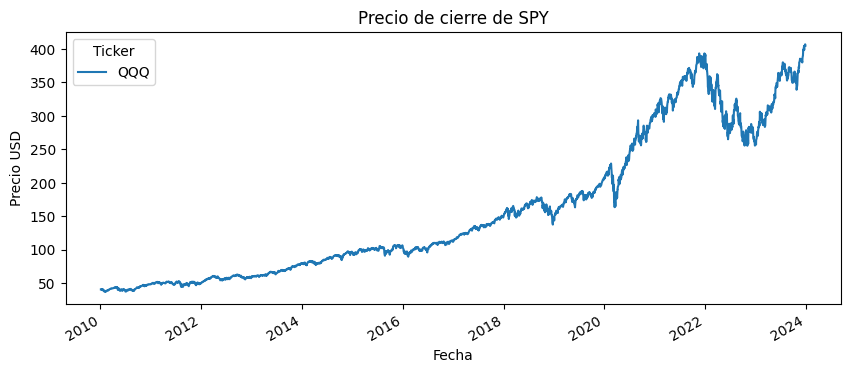

In [4]:
## Grafico de precios de cierre
df['Close'].plot(figsize=(10, 4), title='Precio de cierre de SPY')
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.show()

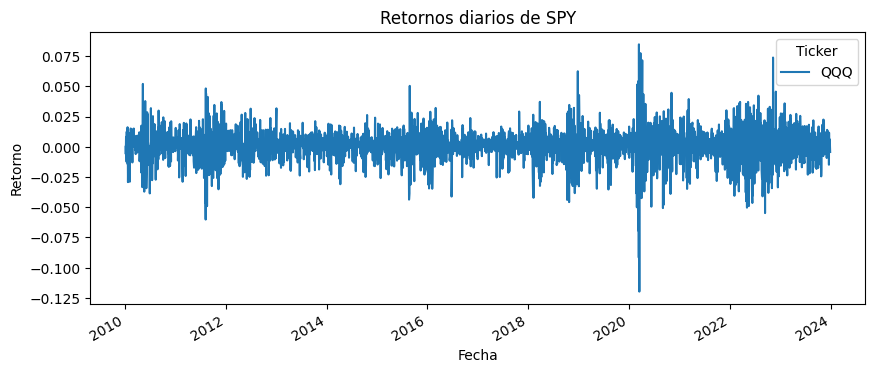

In [5]:
## Grafico de retornos
retornos = df['Close'].pct_change()
retornos.plot(figsize=(10, 4), title='Retornos diarios de SPY')
plt.ylabel('Retorno')
plt.xlabel('Fecha')
plt.show()

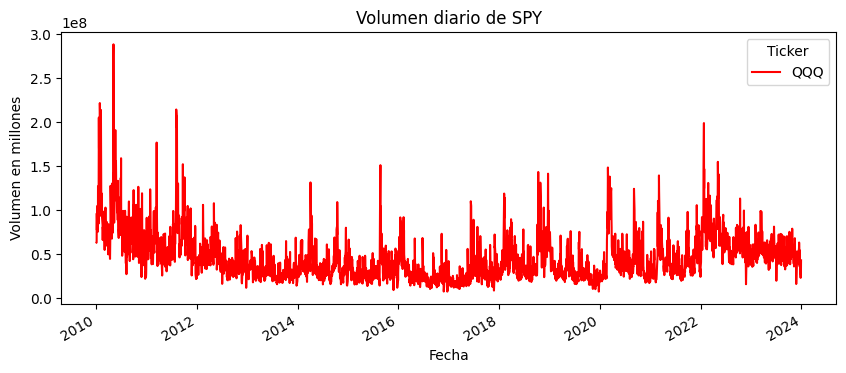

In [6]:
## Grafico de volumen
volumen = df['Volume']
volumen.plot(figsize=(10, 4), title='Volumen diario de QQQ', color="red",)
plt.ylabel('Volumen en millones')
plt.xlabel('Fecha')
plt.show()

In [7]:
## Indicadores tecnicos:Promedios moviles
ventanas = [9, 10, 14, 20, 21, 50]
for i in ventanas:
    df[f"MA_{i}"] = df["Close"].rolling(i, min_periods=i).mean()
#Datos con nuevas variables
df

Price,Close,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,,,,,,
Date,,,,,,,,,,,
2010-01-04,40.341591,40.402428,40.211234,40.263379,62822800,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,40.341591,40.411117,40.115638,40.315520,62935600,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,40.098259,40.454572,40.037425,40.324215,96033000,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,40.124329,40.211236,39.907065,40.159092,77094100,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,40.454578,40.454578,39.915764,40.037432,88886600,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,403.706635,405.278435,401.828384,404.319535,34314000,400.189392,399.191891,394.714314,391.447392,391.106325,374.917473
2023-12-26,406.177979,406.850189,404.467765,404.566627,22722500,401.617822,400.788251,396.434544,392.558813,392.148849,375.833433


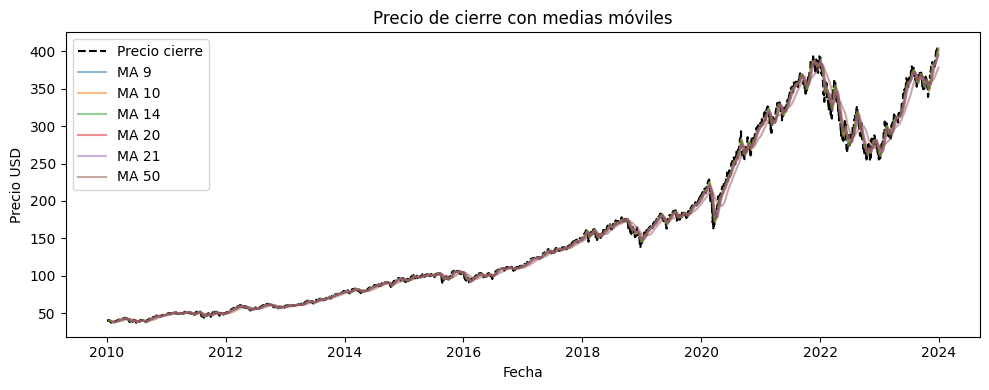

In [8]:
plt.figure(figsize=(10, 4))
# Precio de cierre en negro (sin opacidad)
plt.plot(df.index, df["Close"], label="Precio cierre", color='black', linestyle='--')
# Medias móviles con opacidad 0.5
for i in ventanas:
    plt.plot(df.index, df[f"MA_{i}"], label=f"MA {i}", alpha=0.5)

plt.title("Precio de cierre con medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
## Indicador RSI
import numpy as np
import pandas as pd

def Relative_Strength_Index(df: pd.DataFrame, longitud: int = 14) -> pd.Series:
    """
    Calcula el Índice de Fuerza Relativa (RSI).
    """
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.ewm(alpha=1/longitud, min_periods=longitud).mean()
    avg_loss = loss.ewm(alpha=1/longitud, min_periods=longitud).mean()

    rs = avg_gain / avg_loss

    # Asegura que sea un vector 1D
    rsi_values = np.where(rs == 0, 100, 100 - (100 / (1 + rs)))
    rsi_values = rsi_values.ravel()  # ← Convierte a vector 1D si está en forma (n,1)

    rsi = pd.Series(rsi_values, index=df.index, name=f"RSI_{longitud}")
    return rsi


In [10]:
## Agregar indicador
ventanas = [9, 10, 14, 20, 21, 50]

for i in ventanas:
    df[f"RSI_{i}"] = Relative_Strength_Index(df, longitud=i)

fig = make_subplots (rows=3, cols=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_9"], name= "RSI_9"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_10"], name= "RSI_10"), row=1, col=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_14"], name= "RSI_14"), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_20"], name= "RSI_20"), row=2, col=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_21"], name= "RSI_21"), row=3, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_50"], name= "RSI_50"), row=3, col=2)

fig.update_layout(title= "Analisis de RSI para diferenres ventanas de tiempo")
fig.show()

In [11]:
### Indicador MACD
df["EMA_12"] = df["Close"].ewm(span=12, min_periods=12).mean()
df["EMA_26"] = df["Close"].ewm(span=26, min_periods=26).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_signal"] = df["MACD"].ewm(span=9, min_periods=9).mean()
print(df.head())

Price           Close       High        Low       Open    Volume MA_9 MA_10  \
Ticker            QQQ        QQQ        QQQ        QQQ       QQQ              
Date                                                                          
2010-01-04  40.341591  40.402428  40.211234  40.263379  62822800  NaN   NaN   
2010-01-05  40.341591  40.411117  40.115638  40.315520  62935600  NaN   NaN   
2010-01-06  40.098259  40.454572  40.037425  40.324215  96033000  NaN   NaN   
2010-01-07  40.124329  40.211236  39.907065  40.159092  77094100  NaN   NaN   
2010-01-08  40.454578  40.454578  39.915764  40.037432  88886600  NaN   NaN   

Price      MA_14 MA_20 MA_21  ... RSI_9 RSI_10 RSI_14 RSI_20 RSI_21 RSI_50  \
Ticker                        ...                                            
Date                          ...                                            
2010-01-04   NaN   NaN   NaN  ...   NaN    NaN    NaN    NaN    NaN    NaN   
2010-01-05   NaN   NaN   NaN  ...   NaN    NaN    NaN  

In [12]:
## Realiazar grafico
fig= make_subplots(rows=2, cols=1)
fig.add_trace(go.Scatter(x=df.index, y=df["Close"], name="Close"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["EMA_12"], name="EMA_12"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["EMA_26"], name="EMA_26"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["MACD"], name="MACD"), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["MACD_signal"], name="MACD_signal"), row=2, col=1)
fig.show()


In [13]:
## Limpiar datos y ajustarlos
### Desplazar 1 posición todos los datos para predecir con los de un dia anterior (excepto cloe que es el targuet)
Close= df["Close"]
df=df.shift(periods=1)
df["Close"] = Close
## Eliminar Nan
df.dropna(inplace=True)
df

Price,Close,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,...,RSI_9,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-17,41.427929,41.375775,41.045533,41.184582,74950600.0,40.765497,40.651844,40.230476,39.796259,39.735321,...,82.694327,80.816692,74.338252,68.152190,67.419915,58.827809,40.498596,39.817558,0.681038,0.513063
2010-03-18,41.566982,41.627815,41.306262,41.375788,75643500.0,40.950897,40.831740,40.421049,39.930964,39.873957,...,83.752443,81.840575,75.239161,68.907923,68.156789,59.327149,40.641599,39.939247,0.702352,0.551035
2010-03-19,41.315540,41.610434,41.367096,41.462693,77829400.0,41.085120,41.012506,40.611622,40.060454,40.008869,...,85.020520,83.075792,76.340051,69.835215,69.061037,59.937328,40.783990,40.062065,0.721924,0.585296
2010-03-22,41.689625,41.715732,41.167641,41.689630,86337100.0,41.182714,41.108162,40.743886,40.178241,40.120220,...,73.371404,73.087358,70.257156,66.083805,65.528039,58.322888,40.865778,40.156514,0.709264,0.610138
2010-03-23,41.976723,41.854924,41.106737,41.150236,71902800.0,41.296766,41.233405,40.894180,40.318644,40.250212,...,78.338869,77.549457,73.624416,68.715623,68.079023,59.960167,40.992539,40.271886,0.720653,0.632275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,403.706635,403.469398,399.841383,402.401741,45568900.0,398.690253,397.512161,393.102254,390.476309,390.207323,...,70.798232,70.934237,70.483293,68.538820,68.183895,61.727967,396.195389,388.448015,7.747374,7.112183
2023-12-26,406.177979,405.278435,401.828384,404.319535,34314000.0,400.189392,399.191891,394.714314,391.447392,391.106325,...,71.518467,71.583563,70.957654,68.888230,68.519485,61.888977,397.350965,389.578283,7.772682,7.244283


In [14]:
#División

#       Entrenamiento: la parte mas importante del modelo en cuanto a que el proceso de aprender.
#       Validación: Ajustar hiperparametros del modelo y evaluar su rendieminto sobre el entrenamiento.
#       Prueba: Utiza para evaluar el rendimiento del modelo - se utiliza para ver la capacidad del modelo

tamaño_prueba = 0.10  ## 10% del total de los datos.
tamaño_validacion = 0.10

## Indices de división ára el conjunto de datos
indice_division_prueba = int(df.shape[0]* (1- tamaño_prueba))
indice_division_validacion = int(df.shape[0]* (1- (tamaño_validacion + tamaño_prueba)))

In [15]:
indice_division_prueba, indice_division_validacion

(3124, 2777)

In [16]:
### desde 0 hasta 2777 sera el tamaño de los datos de entrenamiento
### desde 2777 hasta 3124 sera el tamaño de los datos de validación
### desde 3124 hasta 3472 sera los datos de prueba.

In [17]:
## conjuntos de datos de entrenamiento, validación y prueba
conjunto_entrenamiento = df.iloc[:indice_division_validacion].copy() #80%
conjunto_validacion = df.iloc[indice_division_validacion+1: indice_division_prueba].copy() #10%
conjunto_prueba = df.iloc[indice_division_prueba+1:].copy() #10%

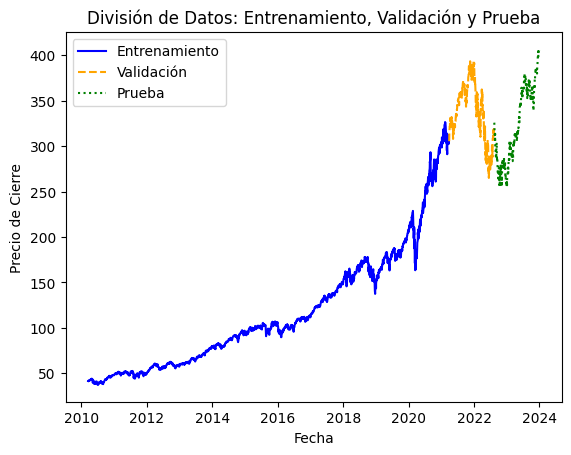

In [18]:
# Graficar cada conjunto con estilo diferenciado
plt.plot(conjunto_entrenamiento.index, conjunto_entrenamiento["Close"], label="Entrenamiento", color="blue")
plt.plot(conjunto_validacion.index, conjunto_validacion["Close"], label="Validación", color="orange", linestyle="--")
plt.plot(conjunto_prueba.index, conjunto_prueba["Close"], label="Prueba", color="green", linestyle=":")

plt.title("División de Datos: Entrenamiento, Validación y Prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre")
plt.legend(loc="best")
plt.show()


In [19]:
##Eliminar columnas
columnas_eliminar= ["Open", "High", "Low", "Volume"]

conjunto_entrenamiento = conjunto_entrenamiento.drop(columns=columnas_eliminar)
conjunto_validacion= conjunto_validacion.drop(columns=columnas_eliminar)
conjunto_prueba = conjunto_prueba.drop(columns=columnas_eliminar)
# Verificación rápida
print(conjunto_entrenamiento.columns)

MultiIndex([(      'Close', 'QQQ'),
            (       'MA_9',    ''),
            (      'MA_10',    ''),
            (      'MA_14',    ''),
            (      'MA_20',    ''),
            (      'MA_21',    ''),
            (      'MA_50',    ''),
            (      'RSI_9',    ''),
            (     'RSI_10',    ''),
            (     'RSI_14',    ''),
            (     'RSI_20',    ''),
            (     'RSI_21',    ''),
            (     'RSI_50',    ''),
            (     'EMA_12',    ''),
            (     'EMA_26',    ''),
            (       'MACD',    ''),
            ('MACD_signal',    '')],
           names=['Price', 'Ticker'])


In [20]:
## dividir caracteristicas y etiquetas
X_entrenamiento = conjunto_entrenamiento.drop(columns=["Close"])
y_entrenamiento = conjunto_entrenamiento["Close"]

X_validacion = conjunto_validacion.drop(columns=["Close"])
y_validacion = conjunto_validacion["Close"]

X_prueba = conjunto_prueba.drop(columns=["Close"])
y_prueba = conjunto_prueba["Close"]
X_entrenamiento

Price,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50,RSI_9,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal
Ticker,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,
2010-03-17,40.765497,40.651844,40.230476,39.796259,39.735321,39.230766,82.694327,80.816692,74.338252,68.152190,67.419915,58.827809,40.498596,39.817558,0.681038,0.513063
2010-03-18,40.950897,40.831740,40.421049,39.930964,39.873957,39.252493,83.752443,81.840575,75.239161,68.907923,68.156789,59.327149,40.641599,39.939247,0.702352,0.551035
2010-03-19,41.085120,41.012506,40.611622,40.060454,40.008869,39.277001,85.020520,83.075792,76.340051,69.835215,69.061037,59.937328,40.783990,40.062065,0.721924,0.585296
2010-03-22,41.182714,41.108162,40.743886,40.178241,40.120220,39.301347,73.371404,73.087358,70.257156,66.083805,65.528039,58.322888,40.865778,40.156514,0.709264,0.610138
2010-03-23,41.296766,41.233405,40.894180,40.318644,40.250212,39.332653,78.338869,77.549457,73.624416,68.715623,68.079023,59.960167,40.992539,40.271886,0.720653,0.632275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-22,306.508650,304.964807,303.807783,305.759105,306.495864,311.546432,45.582824,45.707850,46.211252,47.221128,47.400585,51.285351,306.283450,308.005587,-1.722137,-2.079504
2021-03-23,307.289554,306.815646,303.850231,305.592795,305.940986,311.624696,53.235128,52.603974,51.230963,50.852030,50.874980,52.827507,306.790398,308.122107,-1.331709,-1.929945


In [21]:
inicio = time.time()
# parametros
params = {
    "n_estimators": [300, 600],
    "learning_rate": [0.01, 0.05],
    "max_depth": [3, 5],
    "gamma": [0.01, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 10],
    "random_state": [1]
}
# Instancia del modelo base
conjunto_datos = [(X_entrenamiento, y_entrenamiento), (X_validacion, y_validacion)]
modelo=xgb.XGBRegressor(objective="reg:squarederror", verbosity=0)
clf = GridSearchCV(estimator=modelo, param_grid=params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1) # Grid search
clf.fit(X_entrenamiento, y_entrenamiento) # Entrenar el modelo con los datos correctos


final = time.time() - inicio

print("El modelo se tardó en correr: {:.2f} segundos".format(final))
print("Mejores parámetros:", clf.best_params_)
print("Mejor puntuación de validación (neg MSE):", clf.best_score_)


El modelo se tardó en correr: 801.68 segundos
Mejores parámetros: {'colsample_bytree': 1.0, 'gamma': 0.3, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 600, 'random_state': 1, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
Mejor puntuación de validación (neg MSE): -2415.586680094401


In [22]:
##Definir mejor modelo
modelo = xgb.XGBRegressor(**clf.best_params_, objective = "reg:squarederror")
modelo.fit(X_entrenamiento, y_entrenamiento, eval_set=conjunto_datos, verbose=0)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

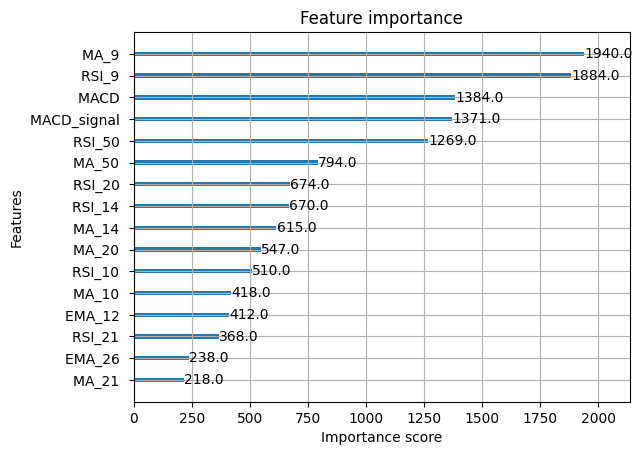

In [23]:
## Graficar el nivel de importancia de cada variables
plot_importance(modelo)

In [24]:
## Predecir los datos de entrenamiento
y_entrenamiento_pred = modelo.predict(X_entrenamiento)
print(f"y_entrenamiento = {np.array(y_entrenamiento)[:5]}")
print(f"y_entrenamiento_pred = {np.array(y_entrenamiento_pred)[:5]}")

y_entrenamiento = [[41.42792892]
 [41.56698227]
 [41.31554031]
 [41.68962479]
 [41.97672272]]
y_entrenamiento_pred = [41.188908 41.2027   41.840034 41.918972 41.928535]


In [25]:
print (f"Error Media Cuadrado = {mean_squared_error(y_entrenamiento, y_entrenamiento_pred)}")

Error Media Cuadrado = 0.3677530884742737


In [26]:
## Predecir los datos de validacion
y_validacion_pred = modelo.predict(X_validacion)
print(f"y_validacion = {np.array(y_validacion)[:5]}")
print(f"y_validacion_pred = {np.array(y_validacion_pred)[:5]}")

y_validacion = [[305.41015625]
 [310.0838623 ]
 [315.36965942]
 [321.66598511]
 [321.4425354 ]]
y_validacion_pred = [304.8449  304.94632 307.46863 309.5191  309.9914 ]


In [27]:
print (f"Error Media Cuadrado = {mean_squared_error(y_validacion, y_validacion_pred)}")

Error Media Cuadrado = 1775.0057373046875


In [28]:
## Predecir los datos de prueba
y_prueba_pred = modelo.predict(X_prueba)
print(f"y_prueba = {np.array(y_prueba)[:5]}")
print(f"y_prueba_pred = {np.array(y_prueba_pred)[:5]}")

y_prueba = [[325.79446411]
 [325.03149414]
 [321.32409668]
 [322.09689331]
 [315.81695557]]
y_prueba_pred = [313.38953 309.55722 315.3462  316.21835 316.53345]


In [29]:
print (f"Error Media Cuadrado = {mean_squared_error(y_prueba, y_prueba_pred)}")

Error Media Cuadrado = 1564.6192626953125


In [30]:
## convertir prediccion en dtaframe
y_entrenamiento_pred = pd.Series(index=X_entrenamiento.index, data=y_entrenamiento_pred)
y_validacion_pred = pd.Series(index=X_validacion.index, data=y_validacion_pred)
y_prueba_pred = pd.Series(index=X_prueba.index, data=y_prueba_pred)

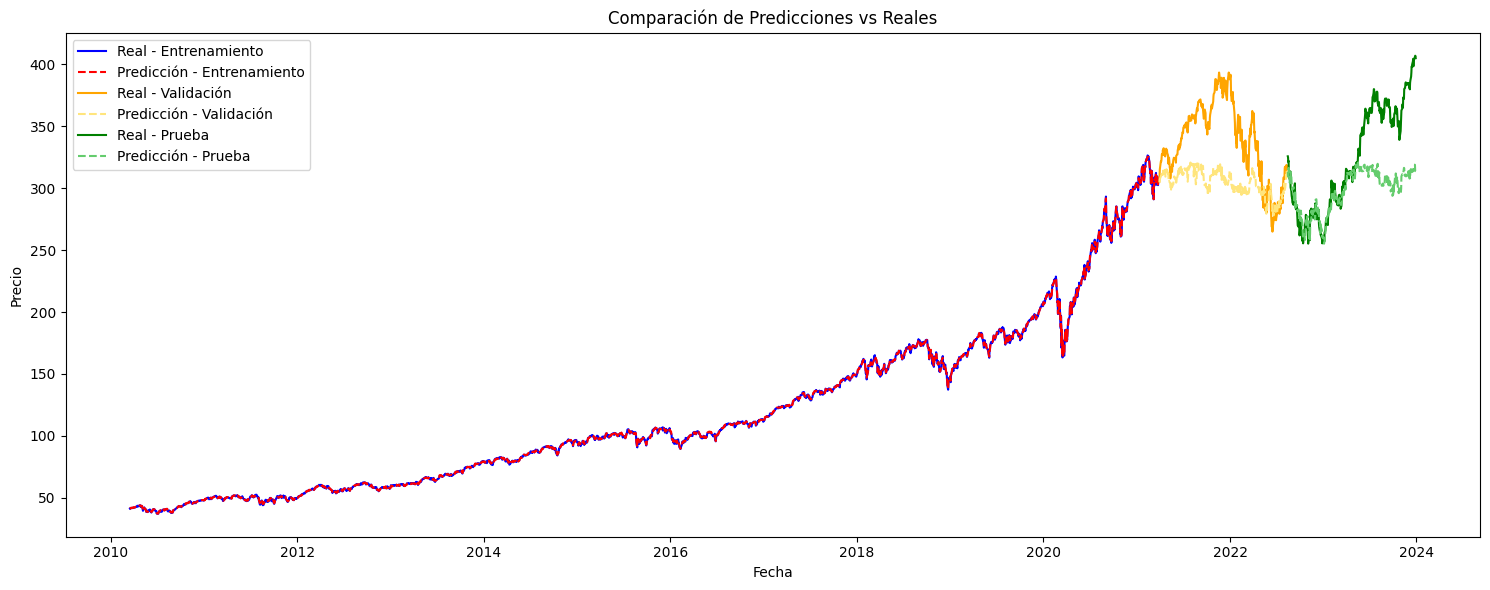

In [31]:
plt.figure(figsize=(15, 6))

# Entrenamiento
plt.plot(y_entrenamiento.index, y_entrenamiento, label="Real - Entrenamiento", color="blue")
plt.plot(y_entrenamiento_pred.index, y_entrenamiento_pred, label="Predicción - Entrenamiento", color="red", linestyle="--")

# Validación
plt.plot(y_validacion.index, y_validacion, label="Real - Validación", color="orange")
plt.plot(y_validacion_pred.index, y_validacion_pred, label="Predicción - Validación", color="#FFE57D", linestyle="--")

# Prueba
plt.plot(y_prueba.index, y_prueba, label="Real - Prueba", color="green")
plt.plot(y_prueba_pred.index, y_prueba_pred, label="Predicción - Prueba", color="#64CC6D", linestyle="--")

# Configuración del gráfico
plt.title("Comparación de Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()